In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

print("✅ TensorFlow imported successfully!")
print("TensorFlow version:", tf.__version__)

# Load the preprocessed data from Step 4
X_train = np.load('../data/processed/X_train.npy')
X_test = np.load('../data/processed/X_test.npy')
y_class_train = np.load('../data/processed/y_class_train.npy')
y_class_test = np.load('../data/processed/y_class_test.npy')

print("✅ Data loaded!")
print("Training shape:", X_train.shape)

✅ TensorFlow imported successfully!
TensorFlow version: 2.20.0
✅ Data loaded!
Training shape: (160000, 42)


In [5]:
# Build simple classification model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')   # Probability of success
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',      # Best for binary classification
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()

s:\IIHMR-B\Advanced Analytics 2\Market_campaign_performance_tensorflow\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,825 (54.00 KB)

 Trainable params: 13,825 (54.00 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train, y_class_train,
    validation_split=0.2,
    epochs=30,
    batch_size=512,          # Good size for your laptop
    callbacks=[early_stop],
    verbose=1
)

print("✅ Training completed!")

Epoch 1/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5030 - auc: 0.5018 - loss: 0.6965 - val_accuracy: 0.4995 - val_auc: 0.5011 - val_loss: 0.6934
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5042 - auc: 0.5062 - loss: 0.6935 - val_accuracy: 0.5007 - val_auc: 0.5001 - val_loss: 0.6933
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5087 - auc: 0.5119 - loss: 0.6930 - val_accuracy: 0.5008 - val_auc: 0.5009 - val_loss: 0.6933
Epoch 4/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5100 - auc: 0.5135 - loss: 0.6929 - val_accuracy: 0.5000 - val_auc: 0.4965 - val_loss: 0.6934
Epoch 5/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5139 - auc: 0.5187 - loss: 0.6926 - val_accuracy: 0.4948 - val_auc: 0.4952 - val_loss: 0.6934
Epoch 6/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5140 - auc: 0.5190 - loss: 0.6925 - val_accuracy: 0.5005 - val_auc: 0.5003 - val_loss: 0.6934
Epoch 7/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 

In [7]:
# Evaluate on unseen test data (simulates future campaigns)
test_loss, test_acc, test_auc = model.evaluate(X_test, y_class_test, verbose=0)

print("🎯 Classification Model Performance on New Campaigns:")
print(f"Test Accuracy     : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Test AUC          : {test_auc:.4f}")

# Business interpretation
success_rate = y_class_test.mean() * 100
print(f"\nBusiness Insight:")
print(f"→ Model is {test_acc*100 - 50:.1f}% better than random guessing")
print(f"→ Out of 40,000 future campaigns, it can correctly classify ~{test_acc*40000:.0f} of them")

🎯 Classification Model Performance on New Campaigns:
Test Accuracy     : 0.4979 (49.79%)
Test AUC          : 0.4971

Business Insight:
→ Model is -0.2% better than random guessing
→ Out of 40,000 future campaigns, it can correctly classify ~19916 of them


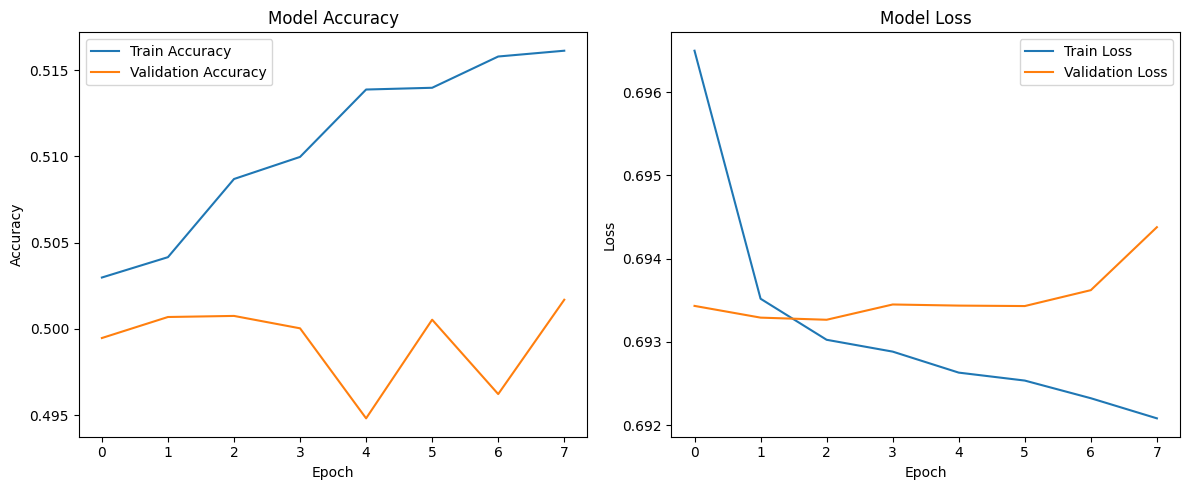

In [8]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

In [9]:
# Save model
model.save('../models/classification_model.h5')
print("✅ Classification model saved as 'classification_model.h5'")

✅ Classification model saved as 'classification_model.h5'
